In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import zscore
from scipy import stats

df = pd.read_csv("../data/cleaned_superstore.csv")

In [38]:
print(df.shape)
print(df.columns)
print(df.describe())

(9994, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')
            Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.80000

In [39]:
print("Mean:", df["Sales"].mean())


Mean: 229.85800083049833


In [40]:
print("Median:", df["Sales"].median())

Median: 54.489999999999995


In [41]:

print("Mode:", df["Sales"].mode())

Mode: 0    12.96
Name: Sales, dtype: float64


In [42]:
print("Standard Deviation:", df["Sales"].std())

Standard Deviation: 623.2451005086807


In [43]:

print("Variance:", df["Sales"].var())

Variance: 388434.4553080756


In [44]:
print("Q1:", df["Sales"].quantile(0.25))
print("Q2:", df["Sales"].quantile(0.50))
print("Q3:", df["Sales"].quantile(0.75))

Q1: 17.28
Q2: 54.489999999999995
Q3: 209.94


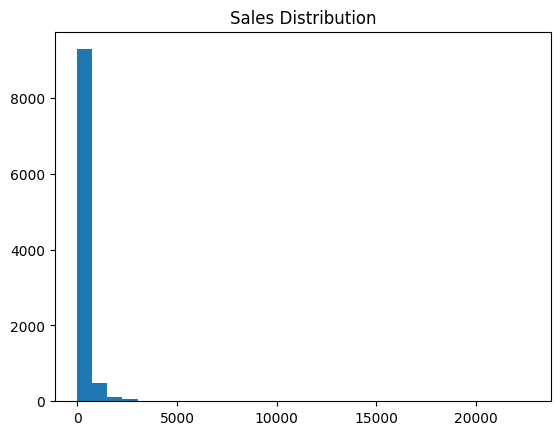

In [45]:
plt.hist(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.show()

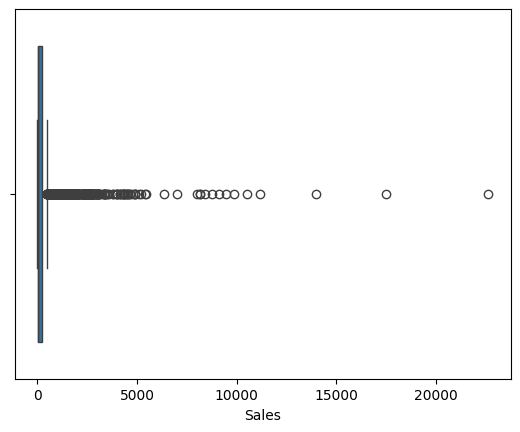

In [46]:
sns.boxplot(x=df["Sales"])
plt.show()

In [47]:
print(df["Sales"].corr(df["Profit"]))

0.4790643497377061


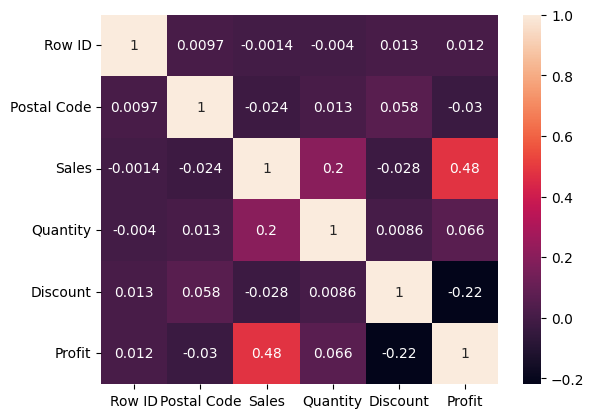

In [48]:
corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True)

plt.show()

In [49]:
print("Skewness:", df["Sales"].skew())

Skewness: 12.97275234181623


In [50]:
print("Kurtosis:", df["Sales"].kurt())

Kurtosis: 305.311753246823


In [51]:
print(
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [52]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Sales"] < lower) |
    (df["Sales"] > upper)
]

print(outliers.shape)

(1167, 21)


In [53]:
print("Minimum Sales:", df["Sales"].min())
print("Maximum Sales:", df["Sales"].max())

Minimum Sales: 0.444
Maximum Sales: 22638.48


In [54]:
sales_range = df["Sales"].max() - df["Sales"].min()

print("Sales Range:", sales_range)

Sales Range: 22638.036


In [55]:
print("Total Sales:", df["Sales"].sum())

Total Sales: 2297200.8603000003


In [56]:
print("Total Profit:", df["Profit"].sum())

Total Profit: 286397.0217


In [57]:
print(
    df.groupby("Category")["Profit"]
    .sum()
)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


In [58]:
print(
    df.groupby("Region")["Sales"]
    .sum()
)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


In [59]:
print(df["Customer Name"].nunique())

793


In [60]:
print(df["Product Name"].nunique())

1850


In [61]:
print(
    df.nlargest(5, "Sales")
)

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
2697    2698  CA-2014-145317   3/18/2014   3/23/2014  Standard Class   
6826    6827  CA-2016-118689   10/2/2016   10/9/2016  Standard Class   
8153    8154  CA-2017-140151   3/23/2017   3/25/2017     First Class   
2623    2624  CA-2017-127180  10/22/2017  10/24/2017     First Class   
4190    4191  CA-2017-166709  11/17/2017  11/22/2017  Standard Class   

     Customer ID Customer Name      Segment        Country           City  \
2697    SM-20320   Sean Miller  Home Office  United States   Jacksonville   
6826    TC-20980  Tamara Chand    Corporate  United States      Lafayette   
8153    RB-19360  Raymond Buch     Consumer  United States        Seattle   
2623    TA-21385  Tom Ashbrook  Home Office  United States  New York City   
4190    HL-15040  Hunter Lopez     Consumer  United States         Newark   

      ... Postal Code   Region       Product ID    Category Sub-Category  \
2697  ...       32216    Sou

In [62]:
print(
    df.groupby("Segment")["Profit"]
    .sum()
)

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


In [63]:
print(
    df.nlargest(5, "Profit")
)

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
6826    6827  CA-2016-118689   10/2/2016   10/9/2016  Standard Class   
8153    8154  CA-2017-140151   3/23/2017   3/25/2017     First Class   
4190    4191  CA-2017-166709  11/17/2017  11/22/2017  Standard Class   
9039    9040  CA-2016-117121  12/17/2016  12/21/2016  Standard Class   
4098    4099  CA-2014-116904   9/23/2014   9/28/2014  Standard Class   

     Customer ID  Customer Name    Segment        Country         City  ...  \
6826    TC-20980   Tamara Chand  Corporate  United States    Lafayette  ...   
8153    RB-19360   Raymond Buch   Consumer  United States      Seattle  ...   
4190    HL-15040   Hunter Lopez   Consumer  United States       Newark  ...   
9039    AB-10105  Adrian Barton   Consumer  United States      Detroit  ...   
4098    SC-20095   Sanjit Chand   Consumer  United States  Minneapolis  ...   

     Postal Code   Region       Product ID         Category Sub-Category  \
6826       47905

In [64]:
print(df["Sales"].describe())

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64


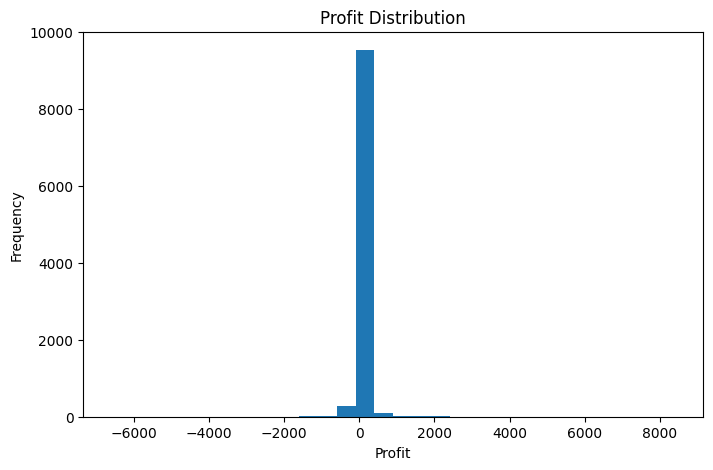

In [65]:
plt.figure(figsize=(8,5))

plt.hist(df["Profit"], bins=30)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

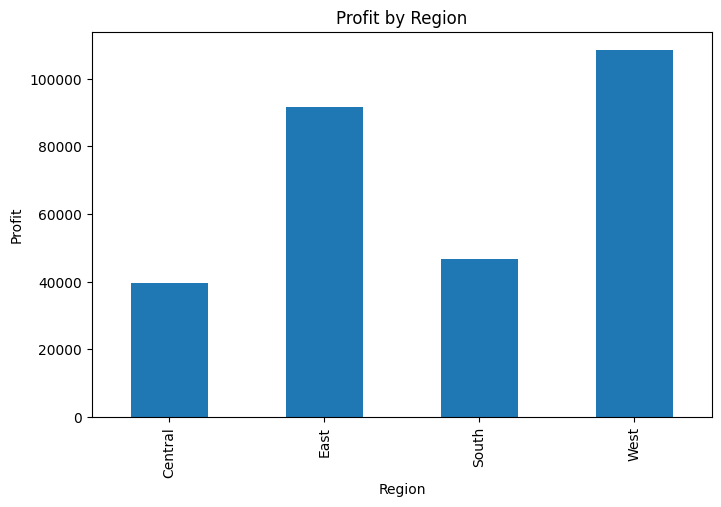

In [66]:
region_profit = df.groupby("Region")["Profit"].sum()

region_profit.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()